In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

import boto3
import os

session = boto3.Session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")
)

In [2]:
import mlflow

mlflow.set_tracking_uri("http://ec2-98-89-26-222.compute-1.amazonaws.com:5000")

In [3]:
mlflow.set_experiment('Exp 3 - TfIdF trigram max_features')

2026/03/04 00:33:55 INFO mlflow.tracking.fluent: Experiment with name 'Exp 3 - TfIdF trigram max_features' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://mlflow-bucket-carlos/3', creation_time=1772595235265, experiment_id='3', last_update_time=1772595235265, lifecycle_stage='active', name='Exp 3 - TfIdF trigram max_features', tags={}>

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [6]:
df = pd.read_csv('reddit_preprocessing.csv')
df.dropna(inplace = True)
print(df.shape)

df.head()

(36662, 2)


,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


|||||||||||||||||||| 1000
🏃 View run RFIDF_Trigrams_max_features_1000 at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/3/runs/2481c53ab41a40d780908de6294bdd23
🧪 View experiment at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/3
Accuracy: 0.6618028092186008
|||||||||||||||||||| 2000
🏃 View run RFIDF_Trigrams_max_features_2000 at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/3/runs/242eef9cb94444d987bc8e2996f89738
🧪 View experiment at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/3
Accuracy: 0.6592117823537433
|||||||||||||||||||| 3000
🏃 View run RFIDF_Trigrams_max_features_3000 at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/3/runs/201560ce81914e2797dfdca014677034
🧪 View experiment at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/3
Accuracy: 0.6538933587890359
|||||||||||||||||||| 4000
🏃 View run RFIDF_Trigrams_max_features_4000 at: http://ec2-98-89-26-222

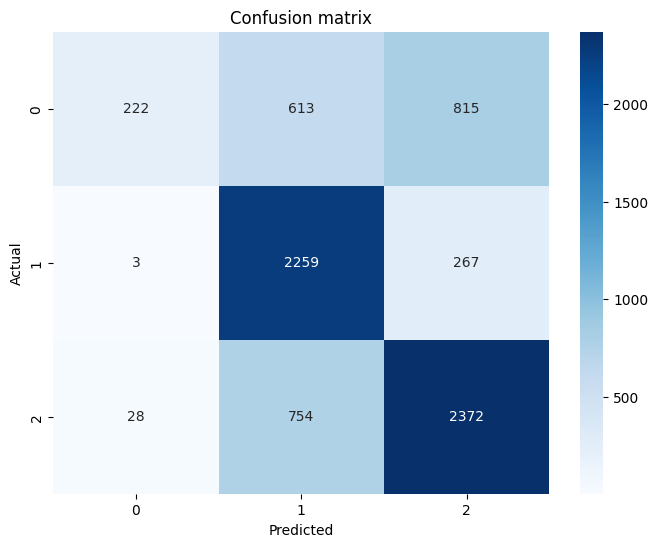

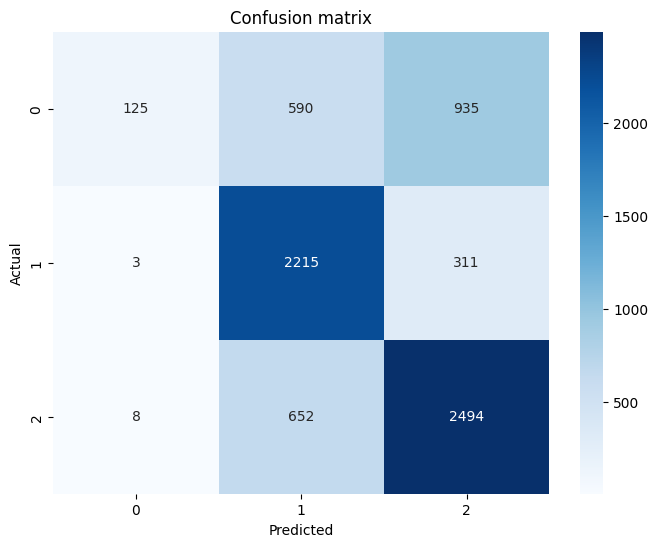

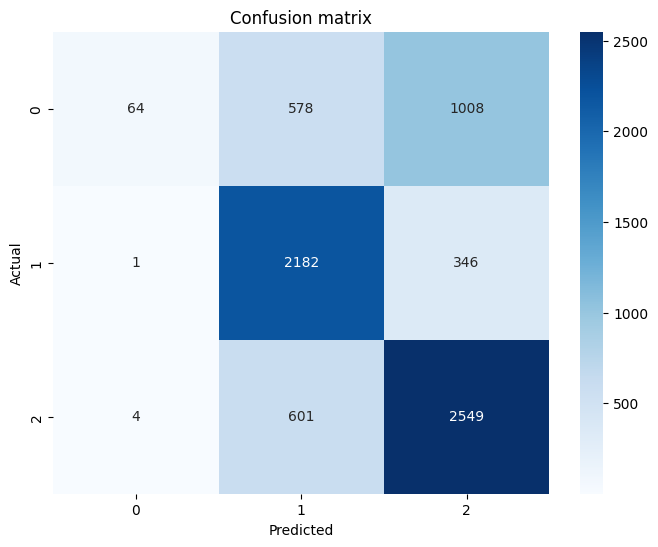

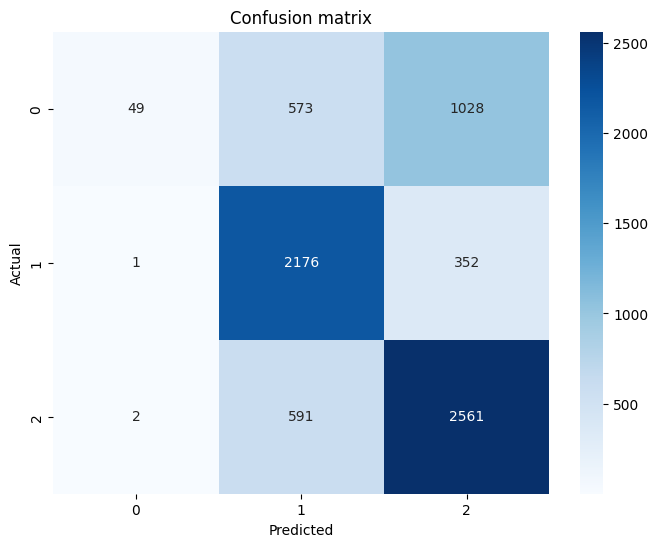

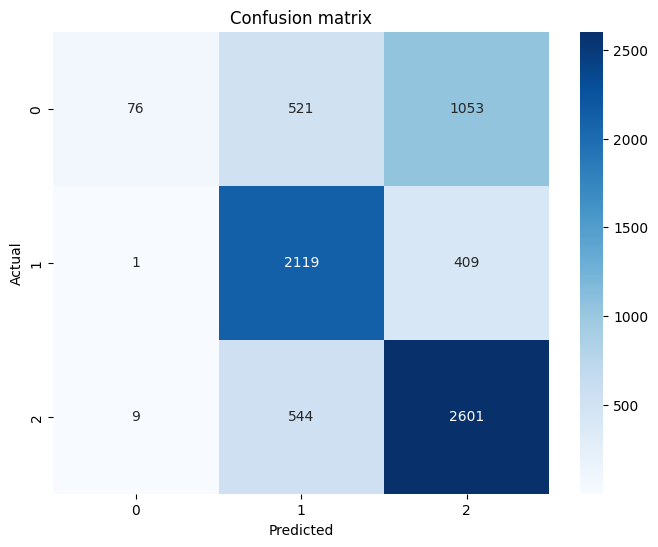

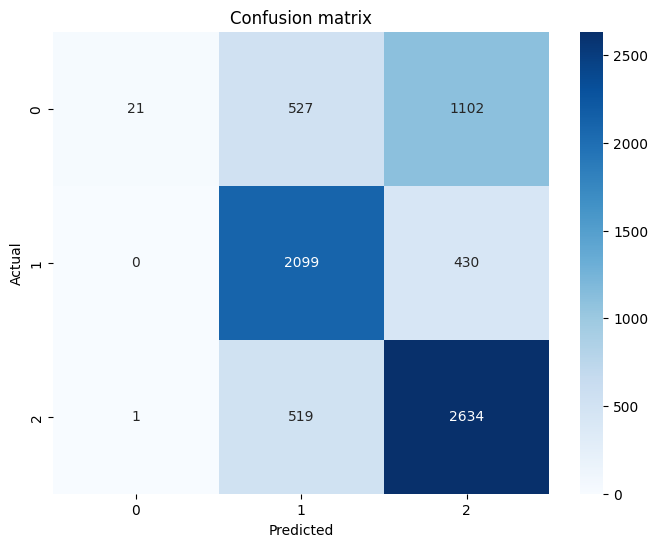

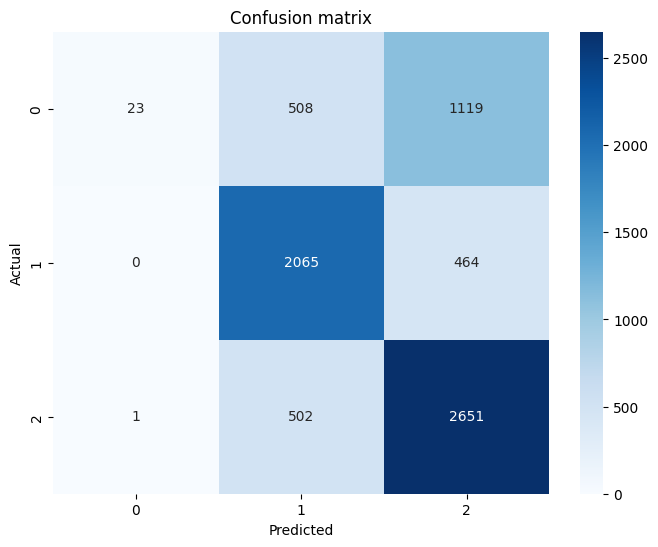

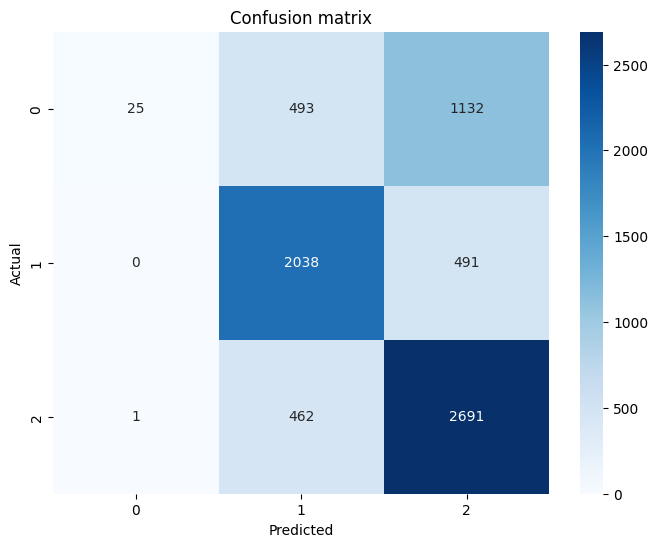

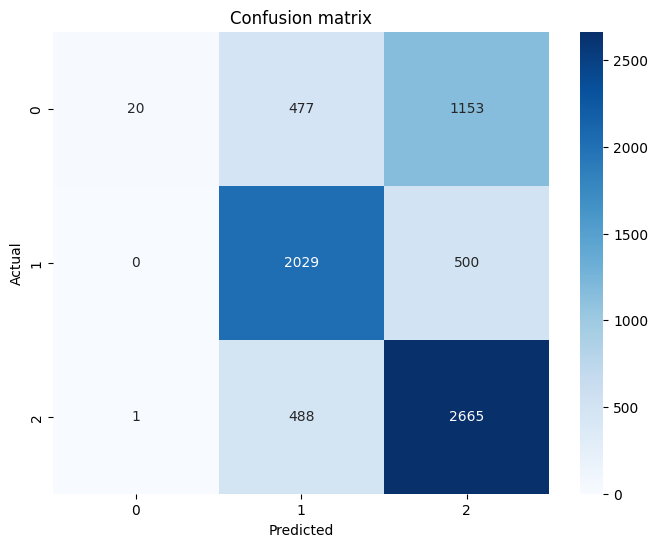

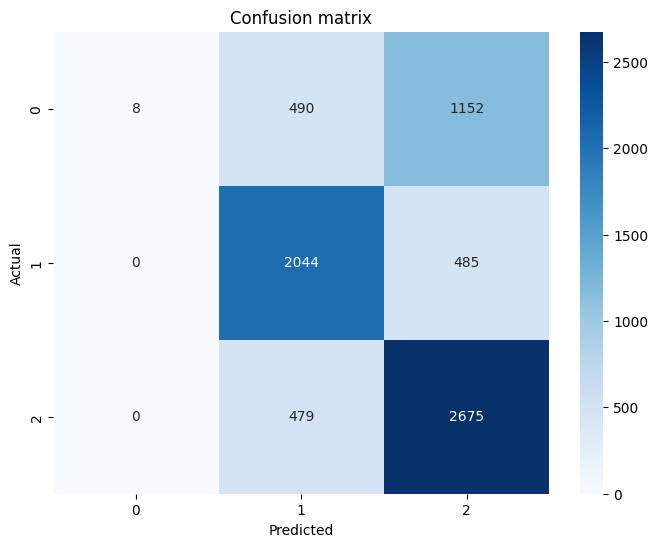

In [9]:
def run_experiment_tfidf_max_features(max_features):
    ngram_range = (1,3)
    
    vectorizer = TfidfVectorizer(ngram_range = ngram_range, max_features = max_features)
    
    X_train, X_test, y_train, y_test = train_test_split(df.clean_comment, df.category, test_size = 0.2, random_state = 42, stratify = df.category)
    
    X_train = vectorizer.fit_transform(X_train)
    X_test = vectorizer.transform(X_test)
    
    with mlflow.start_run() as run:
        mlflow.set_tag('mlflow.runName', f'RFIDF_Trigrams_max_features_{max_features}')
        mlflow.set_tag('experiment_type','feature_engineering')
        mlflow.set_tag('model_type','RandomForestClassifier')
        
        mlflow.set_tag('description',f'RandomForest with TF-IDF Trigrams, max_features = {max_features}')
        
        mlflow.log_param('vectorizer_type','TF-IDF')
        mlflow.log_param('ngram_range', ngram_range)
        mlflow.log_param('vectorizer_max_features',max_features)
        
        n_estimators = 200
        max_depth = 15
        
        mlflow.log_param('max_estimators', n_estimators)
        mlflow.log_param('max_depth', max_depth)
        
        model = RandomForestClassifier(n_estimators = n_estimators, max_depth = max_depth, random_state = 42)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        mlflow.log_metric('accuracy', accuracy)
        
        classification_rep = classification_report(y_test, y_pred, output_dict = True)
    
        for label, metrics in classification_rep.items():
            if isinstance(metrics, dict):
                for metric, value in metrics.items():
                    mlflow.log_metric(f'{label}_{metric}', value)
                    
        conf_matrix = confusion_matrix(y_test, y_pred)
        plt.figure(figsize = (8,6))
        sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Blues')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion matrix')
        
        plt.savefig('confusion_matrix.png')
        mlflow.log_artifact("confusion_matrix.png")
        
        df.to_csv('dataset.csv', index = False)
        mlflow.log_artifact('dataset.csv')
        
        mlflow.sklearn.log_model(
            model,
            f"random_forest_model_tfidf_trigrams_{max_features}",
            input_example=X_train[:5]
        )
        
    print(f'Accuracy: {accuracy}')
    
max_features_values = [1000*(i+1) for i in range(10)]

for max_feature in max_features_values:
    print('||'*10,max_feature)
    run_experiment_tfidf_max_features(max_feature)